<a href="https://colab.research.google.com/github/swarnankeedeb447-lgtm/SPA613M/blob/main/261310614_SPA613M_Programming_Assignment_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SPA613M Programming Assignment

You are part of an **IIT Kanpur** Celestial observing team studying **FRB 20220912A**, a repeating fast radio burst. This is one continuous assignment: it begins with units and time, moves through coordinate transformations and spherical calculations, develops the geometry and visibility of a source from GTC, and ends by answering progressively harder observing questions involving a FRB and a one-year all-sky GTC visibility infographic.

Use **UTC internally** for astronomical calculations. Whenever you report a civil clock time, show **IIT Kanpur time—Indian Standard Time (IST, `Asia/Kolkata`, UTC+05:30)** and retain UTC where requested.

**Total: 40 marks**  
**Optional:** Q20 carries 2 bonus marks.


## Marking Scheme

| Part | Questions | Topic | Marks |
|---|---:|---|---:|
| A | Q1–Q3 | Current time, quantities, conversions, JD/MJD, and IST | 5 |
| B | Q4–Q7 | Angles, coordinate systems, and angular separation | 8 |
| C | Q8–Q13 | GTC, LST, hour angle, transit, and altitude calculations | 12 |
| D | Q14–Q17 | Airmass, Sun, Moon, and practical visibility decisions | 9 |
| E | Q18 | Observing interval, GTC airmass figure, and interpretation | 4 |
| F | Q19 | Single-FRB visibility | 2 |
| Bonus extension | Q20 | One-year all-sky GTC animation | 2 bonus |
| **Assessed total** | **Q1–Q19** |  | **40** |


## Fixed target record

FRB 20220912A is a repeating fast radio burst. Use the following published VLBI position throughout the assignment:

- Source: `FRB 20220912A`
- ICRS/J2000 RA: `23h09m04.8989s`
- ICRS/J2000 Dec: `+48d42m23.9078s`
- Coordinate uncertainty: `5 mas`
- Dispersion measure: $219.46\,\mathrm{pc\,cm^{-3}}$
- Host redshift: $0.0771$

Source: Hewitt et al., *Milliarcsecond localization of the hyperactive repeating FRB 20220912A*, MNRAS 529, 1814–1830. The values above are frozen, so no catalogue or web query is required. [Published article](https://academic.oup.com/mnras/article/529/2/1814/7623035)

## Fixed GTC observing case

| Item | Course value |
|---|---|
| Observatory | Gran Telescopio Canarias (GTC) |
| Longitude | $-17.889^\circ$ |
| Latitude | $+28.758^\circ$ |
| Height | $2396\,\mathrm{m}$ |
| Calculation interval | `2026-08-30T12:00:00Z` through `2026-08-31T12:00:00Z` |
| Sampling | 10 minutes; both endpoints included; 145 samples |
| Minimum target altitude | $20^\circ$ |
| Permitted target airmass | finite $1\leq X\leq2.5$ |
| Astronomical darkness | Sun altitude $\leq-18^\circ$ |
| Minimum Moon separation | $30^\circ$ |

A target is observable only when **all four** target-altitude, target-airmass, Sun, and Moon-separation conditions pass simultaneously.

## Setup

Run the dependency cell before Q1. The setup supplies imports, fixed course constants, a reproducible offline astronomy configuration, an inclusive 145-sample UTC grid, IIT Kanpur formatting helpers, and a relative output directory.

In [ ]:
import subprocess
import sys

REQUIRED_PACKAGES = [
    "numpy>=1.26",
    "matplotlib>=3.8",
    "astropy>=6.0",
    "astropy-iers-data",
    "tzdata",
    "healpy>=1.18",
    "astroplan>=0.10",
    "imageio>=2.31",
]

subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--disable-pip-version-check",
        *REQUIRED_PACKAGES,
    ]
)
print("Dependencies installed: NumPy, Matplotlib, Astropy, IERS data, timezone data, healpy, astroplan, and imageio.")

Dependencies installed: NumPy, Matplotlib, Astropy, IERS data, timezone data, healpy, astroplan, and imageio.


In [ ]:
from datetime import timezone
from pathlib import Path
from zoneinfo import ZoneInfo

import astropy
import matplotlib
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import healpy as hp
import numpy as np
from astropy import units as u
from astropy.coordinates import (
    AltAz,
    Angle,
    BarycentricTrueEcliptic,
    EarthLocation,
    SkyCoord,
    get_body,
    get_sun,
    solar_system_ephemeris,
)
from astropy.time import Time
from astropy.utils import iers
from astroplan import Observer

# Keep the astronomy calculation reproducible and independent of a live IERS download.
iers.conf.auto_download = False
iers.conf.auto_max_age = None

IITK_TIMEZONE = ZoneInfo("Asia/Kolkata")

FRB_NAME = "FRB 20220912A"
FRB_RA_J2000 = "23h09m04.8989s"
FRB_DEC_J2000 = "+48d42m23.9078s"
EARLIER_POSITION_RA = "23h09m04.9s"
EARLIER_POSITION_DEC = "+48d42m25.4s"

START_UTC = "2026-08-30T12:00:00"
STOP_UTC = "2026-08-31T12:00:00"
STEP_MINUTES = 10

GTC_LONGITUDE_DEG = -17.889
GTC_LATITUDE_DEG = 28.758
GTC_HEIGHT_M = 2396.0

MIN_TARGET_ALTITUDE_DEG = 20.0
MAX_AIRMASS = 2.5
MAX_SUN_ALTITUDE_DEG = -18.0
MIN_MOON_SEPARATION_DEG = 30.0

OUTPUT_DIR = Path("assignment_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# The inclusive 24-hour course grid is provided so you can focus on astronomy.
start_time = Time(START_UTC, scale="utc")
stop_time = Time(STOP_UTC, scale="utc")
step = STEP_MINUTES * u.min
number_of_steps = int(
    np.round(((stop_time - start_time) / step).to_value(u.dimensionless_unscaled))
)
times = start_time + np.arange(number_of_steps + 1) * step
assert len(times) == 145

def format_iitk(time_value):
    """Return one Astropy Time as the IIT Kanpur civil clock."""
    return time_value.to_datetime(timezone=IITK_TIMEZONE).strftime(
        "%Y-%m-%d %H:%M:%S IST"
    )

def format_utc(time_value):
    """Return one Astropy Time with an explicit UTC label."""
    return time_value.utc.strftime("%Y-%m-%d %H:%M:%S UTC")

print("Target:", FRB_NAME)
print("Observatory: Gran Telescopio Canarias (GTC)")
print("Course grid:", len(times), "samples")
print("IIT Kanpur civil timezone:", IITK_TIMEZONE)
print("Astronomical calculations use UTC; civil-time answers also show IST.")

Target: FRB 20220912A
Observatory: Gran Telescopio Canarias (GTC)
Course grid: 145 samples
IIT Kanpur civil timezone: Asia/Kolkata
Astronomical calculations use UTC; civil-time answers also show IST.


# Part A.  Astropy foundations: time, units, and conversions (5 marks)

## Q1. Current UTC and IIT Kanpur time [1 mark]

Call `Time.now()` exactly once and store it as `now`. Print that same instant as ISO UTC and as the IIT Kanpur civil clock with an `IST` label. In one sentence, explain why two separate calls to `Time.now()` need not describe exactly the same instant.

In [ ]:

now = Time.now()

print("Same instant, two clocks")
print("UTC :", format_utc(now))
print("IST :", format_iitk(now))

Same instant, two clocks
UTC : 2026-09-06 15:28:58 UTC
IST : 2026-09-06 20:58:58 IST


**Explanation.** `Time.now()` reads the computer clock at the moment that line runs. Calling it twice
gives two different instants, because time passes between the two calls. Saving one call in `now` is
what makes the UTC line and the IST line show the same moment on two different clocks.

## Q2. Physical quantities and unit conversions [2 marks]

Create Astropy quantities for the GTC height `2396 m`, wavelength `600 nm`, coordinate uncertainty `5 mas`, cadence `10 min`, and radio frequency `1.4 GHz`. Convert them respectively to kilometres, frequency in THz using `u.spectral()`, arcseconds, hours, and wavelength in centimetres using `u.spectral()`. Print every original value beside its converted value.

In [ ]:

height = 2396 * u.m
wavelength = 600 * u.nm
uncertainty = 5 * u.mas
cadence = 10 * u.min
frequency = 1.4 * u.GHz

print("Height     :", height, "-", height.to(u.km))
print("Wavelength :", wavelength, "-", wavelength.to(u.THz, u.spectral()))
print("Uncertainty:", uncertainty, "-", uncertainty.to(u.arcsec))
print("Cadence    :", cadence, "-", cadence.to(u.hour))
print("Frequency  :", frequency, "-", frequency.to(u.cm, u.spectral()))

Height     : 2396.0 m - 2.396 km
Wavelength : 600.0 nm - 499.6540966666666 THz
Uncertainty: 5.0 mas - 0.005 arcsec
Cadence    : 10.0 min - 0.16666666666666666 h
Frequency  : 1.4 GHz - 21.413747 cm


**Explanation.** Metres to kilometres, mas to arcsec and minutes to hours are the same kind of
quantity written on a different scale, so `.to()` is enough. Nanometres and terahertz are not the
same kind of quantity — one is a length, the other a frequency and they are only connected by
$c = \lambda\nu$. `u.spectral()` hands Astropy that let us convert light-related units between wavelength, frequency, energy, and wave number

## Q3. UTC, JD, MJD, IST, and time arithmetic [2 marks]

Construct `planning_start = Time(START_UTC, scale="utc")`. Print UTC, Julian Date, Modified Julian Date, and IIT Kanpur time. Add `2.25 hour` with an Astropy quantity and print the later instant in UTC and IST. Finally verify that converting the original IST-aware Python datetime back into `Time` changes the instant by less than one microsecond.

In [ ]:

planning_start = Time(START_UTC, scale="utc")
print("UTC :", format_utc(planning_start))
print("JD  :", planning_start.jd)
print("MJD :", planning_start.mjd)
print("IST :", format_iitk(planning_start))

later_time = planning_start + 2.25 * u.hour
print()
print("After adding 2.25 hour")
print("UTC :", format_utc(later_time))
print("IST :", format_iitk(later_time))



ist_datetime = planning_start.to_datetime(timezone=IITK_TIMEZONE)
back = Time(ist_datetime)
change = abs((back - planning_start).to(u.us))

print("\nIST datetime:", ist_datetime)
print("Change after going there and back:", change)
assert change < 1 * u.us

UTC : 2026-08-30 12:00:00 UTC
JD  : 2461283.0
MJD : 61282.5
IST : 2026-08-30 17:30:00 IST

After adding 2.25 hour
UTC : 2026-08-30 14:15:00 UTC
IST : 2026-08-30 19:45:00 IST

IST datetime: 2026-08-30 17:30:00+05:30
Change after going there and back: 0.0 us


**Explanation.** JD and MJD count days as one long number, so adding time never involves months or
leap years; MJD is just JD minus 2400000.5 to keep the number small. Adding `2.25 * u.hour` works
because Astropy understands the unit by itself. Nothing is lost going to IST and back, because the
IST datetime carries its time zone, so Astropy knows exactly which UTC moment it means.

# Part B. Angles and coordinate transformations (8 marks)


## Q4. Parse angles and construct an ICRS coordinate [2 marks]

Parse the target RA and Dec with `Angle`, then construct scalar `frb_icrs` with `SkyCoord`. Print RA and Dec in decimal degrees and padded sexagesimal notation. Verify RA $347.2704120833^\circ$ and Dec $+48.7066410556^\circ$ within $10^{-8}$ degree. Explain why RA commonly uses hours while Dec uses degrees.

In [ ]:

ra = Angle(FRB_RA_J2000)
dec = Angle(FRB_DEC_J2000)
frb_icrs = SkyCoord(ra=ra, dec=dec, frame="icrs")

print(f"RA  = {frb_icrs.ra.deg:.10f} deg")
print(f"Dec = {frb_icrs.dec.deg:.10f} deg")
print("RA  =", frb_icrs.ra.to_string(unit=u.hourangle, sep=":", pad=True, precision=4))
print("Dec =", frb_icrs.dec.to_string(unit=u.deg, sep=":", pad=True, alwayssign=True, precision=4))

assert abs(frb_icrs.ra.deg - 347.2704120833) < 1e-8
assert abs(frb_icrs.dec.deg - 48.7066410556) < 1e-8
print("\nBoth match the published position.")

RA  = 347.2704120833 deg
Dec = 48.7066410556 deg
RA  = 23:09:04.8989
Dec = +48:42:23.9078

Both match the published position.


**Explanation.** The sky turns a full $360^\circ$ in one sidereal day, so one hour of right ascension
is exactly $15^\circ$. Writing RA in hours lets an observer subtract it straight from Local Sidereal
Time to get the hour angle, $H = \mathrm{LST} - \alpha$. Declination is not a turning angle — it is a
latitude on the sky, from $-90^\circ$ to $+90^\circ$ . `assert` does nothing if the gap is small and the condition is true and within $10^{-8}$ degree.

## Q5. ICRS to Galactic and back [2 marks]

Transform `frb_icrs` to Galactic coordinates and print Galactic longitude $l$ and latitude $b$. Transform the result back to ICRS, calculate the round-trip separation in microarcseconds, and explain what a tiny non-zero residual represents.

In [ ]:

galactic = frb_icrs.galactic
print(f"l = {galactic.l.deg:.8f} deg")
print(f"b = {galactic.b.deg:.8f} deg")

back = galactic.icrs
gap = frb_icrs.separation(back).to_value(u.uas)

print(f"\nBack to ICRS: RA = {back.ra.deg:.10f} deg, Dec = {back.dec.deg:.10f} deg")
print(f"Round-trip separation = {gap:.6f} microarcsec")

l = 106.06496077 deg
b = -10.78417629 deg

Back to ICRS: RA = 347.2704120833 deg, Dec = 48.7066410556 deg
Round-trip separation = 0.000311 microarcsec


**Explanation.** Galactic latitude $b \approx -10.8^\circ$ means the FRB sits approx eleven degrees
below the plane of the Milky Way, so its signal still passes through a fair amount of our own galaxy. The tiny leftover, far below a microarcsecond, is only the
rounding a computer does when it stores decimals.

`galactic` gives us the same direction written in galactic coordinates instead — the numbers change, the point in the sky does not.

## Q6. ICRS to Ecliptic and back [2 marks]

Transform `frb_icrs` to barycentric true ecliptic coordinates at equinox J2000. Print ecliptic longitude $\lambda$ and latitude $\beta$ in degrees, verify their valid ranges, transform the result back to ICRS, and calculate the round-trip separation in microarcseconds. Explain what the ecliptic plane and the value of $\beta$ mean physically.

In [ ]:

ecliptic = frb_icrs.transform_to(BarycentricTrueEcliptic(equinox="J2000"))
print(f"lambda = {ecliptic.lon.deg:.8f} deg")
print(f"beta   = {ecliptic.lat.deg:.8f} deg")

assert 0 <= ecliptic.lon.deg < 360
assert -90 <= ecliptic.lat.deg <= 90
print("Both values are inside their allowed ranges.")

back = ecliptic.transform_to("icrs")
gap = frb_icrs.separation(back).to_value(u.uas)
print(f"\nRound-trip separation = {gap:.6f} microarcsec")

lambda = 14.41118765 deg
beta   = 48.34695844 deg
Both values are inside their allowed ranges.

Round-trip separation = 0.000000 microarcsec


**Explanation.** The ecliptic is the plane formed by the apparent path of the Sun across the sky over the course of a year, as seen from Earth. Ecliptic latitude $\beta$
measures how far a source is from that plane, and $\beta \approx +48.3^\circ$ puts this FRB well away
from it. That is good news: the Sun can never pass in front of the source, so it is never lost for
part of the year. The leftover from the round trip is rounding again.

## Q7. Angular separation [2 marks]

Construct `earlier_position` from `23h09m04.9s`, `+48d42m25.4s`. Calculate the great-circle separation manually from

$$\cos(\Delta\theta)=\sin\delta_1\sin\delta_2+\cos\delta_1\cos\delta_2\cos(\alpha_2-\alpha_1).$$

Use radians inside NumPy, clip the computed cosine to $[-1,1]$, and report $\Delta\theta$ in arcseconds and milliarcseconds. Compare with `frb_icrs.separation(earlier_position)` and require agreement within $10^{-6}$ arcsecond.

In [ ]:

earlier_position = SkyCoord(ra=Angle(EARLIER_POSITION_RA), dec=Angle(EARLIER_POSITION_DEC), frame="icrs")


ra1, dec1 = np.longdouble([frb_icrs.ra.radian, frb_icrs.dec.radian])
ra2, dec2 = np.longdouble([earlier_position.ra.radian, earlier_position.dec.radian])

cos_theta = np.sin(dec1) * np.sin(dec2) + np.cos(dec1) * np.cos(dec2) * np.cos(ra2 - ra1)
separation = float(np.degrees(np.arccos(np.clip(cos_theta, -1, 1)))) * u.deg

astropy_separation = frb_icrs.separation(earlier_position)
difference = abs(separation - astropy_separation).to_value(u.arcsec)

print(f"By formula : {separation.to_value(u.arcsec):.6f} arcsec = {separation.to_value(u.mas):.1f} mas")
print(f"By Astropy : {astropy_separation.to_value(u.arcsec):.6f} arcsec")
print(f"Difference : {difference:.1e} arcsec")
assert difference < 1e-6

By formula : 1.492240 arcsec = 1492.2 mas
By Astropy : 1.492240 arcsec
Difference : 1.0e-09 arcsec


**Explanation.** The two positions sit about 1.49 arcsec apart. That is far bigger than the 5 mas
VLBI uncertainty, so the older position is less precise measurement, not the same one written
differently.

The `np.longdouble` line is there for a reason. For an angle this small $\cos\Delta\theta$ is almost
exactly 1, and ordinary floats cannot tell numbers that close to 1 apart well enough, so the answer
comes out about $2\times10^{-6}$ arcsec off — just outside the tolerance.

# Part C. GTC geometry, LST, transit, and altitude calculations (12 marks)

## Q8. Define the GTC observing site [1 mark]

Construct `gtc_location` with `EarthLocation.from_geodetic`, attaching units to the frozen longitude, latitude, and height. Print the recovered geodetic values. State what the negative longitude sign means.

In [ ]:

gtc_location = EarthLocation.from_geodetic(lon=GTC_LONGITUDE_DEG * u.deg,
                                           lat=GTC_LATITUDE_DEG * u.deg,
                                           height=GTC_HEIGHT_M * u.m)

print(f"Longitude: {gtc_location.lon.deg:.3f} deg")
print(f"Latitude : {gtc_location.lat.deg:.3f} deg")
print(f"Height   : {gtc_location.height.to_value(u.m):.0f} m")

Longitude: -17.889 deg
Latitude : 28.758 deg
Height   : 2396 m


**Explanation.** A negative longitude means the site is west of Greenwich.

## Q9. Calculate GTC LST and hour angle at one instant [2 marks]

At `2026-08-31T00:00:00Z`, calculate apparent GTC Local Sidereal Time and target hour angle $H=\mathrm{LST}-\alpha$, wrapped at $\pm12$ hours. Print UTC, IIT Kanpur time, LST, and hour angle. From the sign of $H$, state whether the target is east of the meridian, transiting, or west of the meridian.

In [ ]:

instant = Time("2026-08-31T00:00:00", scale="utc")
lst = instant.sidereal_time("apparent", longitude=gtc_location.lon)
hour_angle = Angle(lst - frb_icrs.ra).wrap_at(12 * u.hourangle)

print("UTC:", format_utc(instant))
print("IST:", format_iitk(instant))
print("LST:", lst.to_string(unit=u.hourangle, sep=":", precision=1))
print(f"Hour angle H = {hour_angle.hour:+.3f} h = {hour_angle.deg:+.2f} deg")

if hour_angle.hour < 0:
    print("H is negative, so the target is east of the meridian and still rising.")
elif hour_angle.hour > 0:
    print("H is positive, so the target is west of the meridian and setting.")
else:
    print("H is zero, so the target is transiting right now.")

UTC: 2026-08-31 00:00:00 UTC
IST: 2026-08-31 05:30:00 IST
LST: 21:25:12.2
Hour angle H = -1.731 h = -25.97 deg
H is negative, so the target is east of the meridian and still rising.


**Explanation.** $H \approx -1.73$ h, so the east of the
meridian and climbing. A negative hour angle always means the target has not reached its highest
point yet; $H$ grows steadily and becomes zero at transit.

## Q10. Find the nearest sampled meridian transit [2 marks]

Calculate apparent GTC LST and wrapped hour angle for all 145 samples. Locate the nearest sampled meridian transit by minimizing absolute hour angle. Print the sample index, UTC, IIT Kanpur time, LST, and hour angle. Explain why this is a sampled approximation rather than the exact transit instant.

In [ ]:

lst_grid = times.sidereal_time("apparent", longitude=gtc_location.lon)
hour_angles = Angle(lst_grid - frb_icrs.ra).wrap_at(12 * u.hourangle)

transit_index = np.argmin(abs(hour_angles.hour))
transit_time = times[transit_index]

print("Sample:", transit_index, "out of", len(times) - 1)
print("UTC   :", format_utc(transit_time))
print("IST   :", format_iitk(transit_time))
print("LST   :", lst_grid[transit_index].to_string(unit=u.hourangle, sep=":", precision=1))
print(f"H     = {hour_angles[transit_index].hour:+.4f} h")
print(f"That is {hour_angles[transit_index].hour * 60:+.1f} minutes away from the real transit.")

Sample: 82 out of 144
UTC   : 2026-08-31 01:40:00 UTC
IST   : 2026-08-31 07:10:00 IST
LST   : 23:05:28.6
H     = -0.0601 h
That is -3.6 minutes away from the real transit.


**Explanation.** Real transit happens when $H$ is exactly zero, and there is no reason for that to
land on one of our samples. With samples every 10 minutes, the best we can do is take the one with
the smallest $|H|$, so the real transit is within 5 minutes of it — here about 3.6 minutes away. `wrap_at(12 * u.hourangle)` is the important because without it the answers come out in the range 0 to 24 hours, so a source one hour before the meridian would read as 23 h instead of −1 h

## Q11. Predict transit altitude and zenith distance [2 marks]

For an upper meridian transit, use $h_{\mathrm{transit}}=90^\circ-|\phi-\delta|$, where $\phi$ is GTC latitude and $\delta$ is target declination. Calculate the predicted altitude and the lecture relation $z=90^\circ-h$ for zenith distance. Then transform the target to a vacuum `AltAz` frame for all grid times, find the largest sampled altitude and its zenith distance, and compare the analytic and Astropy values.

In [ ]:

latitude = GTC_LATITUDE_DEG * u.deg
transit_altitude = 90 * u.deg - abs(latitude - frb_icrs.dec)

print(f"Formula: altitude = {transit_altitude.to_value(u.deg):.3f} deg")
print(f"         zenith distance = {90 - transit_altitude.to_value(u.deg):.3f} deg")


altaz_frame = AltAz(obstime=times, location=gtc_location, pressure=0 * u.hPa)
frb_gtc_altaz = frb_icrs.transform_to(altaz_frame)

highest = np.argmax(frb_gtc_altaz.alt.deg)
highest_altitude = frb_gtc_altaz.alt.deg[highest]

print(f"\nAstropy: highest altitude = {highest_altitude:.3f} deg at sample {highest}")
print(f"         zenith distance = {90 - highest_altitude:.3f} deg")
print(f"         UTC {format_utc(times[highest])}")
print(f"\nFormula minus Astropy = {transit_altitude.to_value(u.deg) - highest_altitude:.3f} deg")

Formula: altitude = 70.051 deg
         zenith distance = 19.949 deg

Astropy: highest altitude = 69.884 deg at sample 82
         zenith distance = 20.116 deg
         UTC 2026-08-31 01:40:00 UTC

Formula minus Astropy = 0.167 deg


## Q12. Calculate altitude before, at, and after transit [3 marks]

At samples two hours before transit, nearest transit, and two hours after transit, calculate altitude from

$$\sin h=\sin\phi\sin\delta+\cos\phi\cos\delta\cos H.$$

Print UTC, IST, hour angle, calculated altitude, Astropy altitude, and their difference for all three samples. State the physical pattern you see as the source crosses the meridian.

In [ ]:

two_hours = 2 * 60 // STEP_MINUTES
phi = np.radians(GTC_LATITUDE_DEG)
delta = frb_icrs.dec.radian

samples = [("Two hours before transit", transit_index - two_hours),
           ("At transit", transit_index),
           ("Two hours after transit", transit_index + two_hours)]

for label, i in samples:
    H = hour_angles[i].radian
    sin_altitude = np.sin(phi) * np.sin(delta) + np.cos(phi) * np.cos(delta) * np.cos(H)
    altitude = np.degrees(np.arcsin(sin_altitude))
    astropy_altitude = frb_gtc_altaz.alt.deg[i]

    print(label)
    print("  UTC:", format_utc(times[i]), " IST:", format_iitk(times[i]))
    print(f"  H = {hour_angles[i].hour:+.3f} h")
    print(f"  altitude by formula = {altitude:.3f} deg, by Astropy = {astropy_altitude:.3f} deg,"
          f" difference = {altitude - astropy_altitude:+.3f} deg\n")

Two hours before transit
  UTC: 2026-08-30 23:40:00 UTC  IST: 2026-08-31 05:10:00 IST
  H = -2.066 h
  altitude by formula = 59.032 deg, by Astropy = 58.782 deg, difference = +0.250 deg

At transit
  UTC: 2026-08-31 01:40:00 UTC  IST: 2026-08-31 07:10:00 IST
  H = -0.060 h
  altitude by formula = 70.039 deg, by Astropy = 69.884 deg, difference = +0.155 deg

Two hours after transit
  UTC: 2026-08-31 03:40:00 UTC  IST: 2026-08-31 09:10:00 IST
  H = +1.945 h
  altitude by formula = 60.063 deg, by Astropy = 60.163 deg, difference = -0.100 deg



**Explanation.** The altitude rises to a peak at the meridian and falls again, and the samples two
hours on either side come out at almost the same height. That happens because the hour angle is given by $\cos H$, and $\cos(+H)$ equals $\cos(-H)$ which is same. The small difference between them is
only because our "transit" sample is not exactly at $H = 0$.



## Q13. Calculate how long the source stays above 20 degrees [2 marks]

Solve the altitude equation for the limiting hour angle:

$$\cos H_0=\frac{\sin h_{\min}-\sin\phi\sin\delta}{\cos\phi\cos\delta}.$$

For $h_{\min}=20^\circ$, calculate $H_0$ in degrees and sidereal hours, then estimate the total interval $2H_0$ during which the source is above the altitude limit. Compare this with the number of grid samples above $20^\circ$.

In [ ]:

cos_H0 = ((np.sin(np.radians(MIN_TARGET_ALTITUDE_DEG)) - np.sin(phi) * np.sin(delta))
          / (np.cos(phi) * np.cos(delta)))
print(f"cos(H0) = {cos_H0:+.5f}")

if cos_H0 <= -1:
    print("The source never drops below 20 degrees.")
elif cos_H0 >= 1:
    print("The source never rises above 20 degrees.")
else:
    H0 = np.degrees(np.arccos(cos_H0))
    hours_up = 2 * H0 / 15

    print(f"H0 = {H0:.2f} deg = {H0 / 15:.2f} sidereal hours")
    print(f"Time above 20 deg = {hours_up:.2f} sidereal hours = {hours_up / 1.0027379:.2f} solar hours")

    samples_up = np.sum(frb_gtc_altaz.alt.deg > MIN_TARGET_ALTITUDE_DEG)
    print(f"\nGrid samples above 20 deg: {samples_up} -> {samples_up * STEP_MINUTES / 60:.2f} h")

cos(H0) = -0.03363
H0 = 91.93 deg = 6.13 sidereal hours
Time above 20 deg = 12.26 sidereal hours = 12.22 solar hours

Grid samples above 20 deg: 74 -> 12.33 h


# Part D. Airmass, Sun, Moon, and practical visibility (9 marks)

## Q14. Calculate a physically safe target airmass [2 marks]

Convert `frb_gtc_altaz.secz` to a float array named `target_airmass`. Replace entries with `NaN` whenever the target is at or below the horizon, the value is non-finite, or the value is below 1. Print the finite range, best airmass with UTC and IST, and the number of samples satisfying $1\leq X\leq2.5$. Explain why below-horizon values must not be used.

In [ ]:

target_altitude = frb_gtc_altaz.alt.deg
target_airmass = np.array(frb_gtc_altaz.secz)
target_airmass[(target_altitude <= 0) | (target_airmass < 1)] = np.nan

best = np.nanargmin(target_airmass)

print(f"Airmass runs from {np.nanmin(target_airmass):.3f} to {np.nanmax(target_airmass):.3f}")
print("Samples thrown away:", np.sum(np.isnan(target_airmass)), "of", len(times))
print(f"\nBest airmass = {target_airmass[best]:.3f}")
print("  UTC:", format_utc(times[best]))
print("  IST:", format_iitk(times[best]))
print("\nSamples with airmass between 1 and 2.5:", np.sum(target_airmass <= MAX_AIRMASS))

Airmass runs from 1.065 to 55.338
Samples thrown away: 43 of 145

Best airmass = 1.065
  UTC: 2026-08-31 01:40:00 UTC
  IST: 2026-08-31 07:10:00 IST

Samples with airmass between 1 and 2.5: 68


**Explanation.** Airmass here is $X = \sec z$, only works while the source is up. Once it sets, z passes 90 degrees and
 $\sec z$ goes negative, and a test like `airmass <= 2.5` would
happily accept a source that is under the ground. `NaN` blocks that, because any comparison with `NaN` is False.

The best airmass, 1.065, comes at transit, since airmass is lowest when the source is highest.

### Moon-conditions

Use the following simplified **course classification**. These labels are provided for this assignment; they are not universal observatory definitions.

| Label | Rule |
|---|---|
| `Unknown` | At least one of Moon altitude, Moon–target separation, or illuminated fraction is non-finite. |
| `Gray` | All three inputs are finite and neither the `Bright` nor `Dark` rule below applies. |
| `Bright` | The illuminated fraction is at least 0.70 **and** Moon altitude is above $10^\circ$, **or** Moon–target separation is at most $45^\circ$. |
| `Dark` | Moon altitude is below $0^\circ$, **or** Moon–target separation is at least $90^\circ$ **and** illuminated fraction is at most 0.25. |

Apply `Bright` first and `Dark` second. Therefore, if both rules happen to pass, the final label is `Dark`.

## Q15. Calculate Sun and Moon observing conditions [2 marks]

Using Astropy's built-in ephemeris, calculate arrays of Sun altitude, Moon altitude, Moon airmass, Moon–target separation, and approximate illuminated fraction $f=(1-\cos\epsilon)/2$, where $\epsilon$ is geocentric Sun–Moon elongation. Keep Moon airmass only from 1 to 3 and above the horizon. Classify each sample as Dark, Bright, Gray, or Unknown using the printed course rules, then print the diagnostic values and Moon label at transit.

In [ ]:

with solar_system_ephemeris.set("builtin"):
    sun = get_sun(times)
    moon = get_body("moon", times, location=gtc_location)
    moon_from_earth = get_body("moon", times)
    sun_altitude = sun.transform_to(altaz_frame).alt.deg
    moon_altaz = moon.transform_to(altaz_frame)
    elongation = sun.separation(moon_from_earth)

moon_altitude = moon_altaz.alt.deg
moon_separation = moon_altaz.separation(frb_gtc_altaz).deg
moon_fraction = (1 - np.cos(elongation.radian)) / 2

moon_airmass = np.array(moon_altaz.secz)
moon_airmass[(moon_altitude <= 0) | (moon_airmass < 1) | (moon_airmass > 3)] = np.nan


def moon_label(altitude, separation, fraction):

    if not np.isfinite([altitude, separation, fraction]).all():
        return "Unknown"
    label = "Gray"
    if (fraction >= 0.70 and altitude > 10) or separation <= 45:
        label = "Bright"
    if altitude < 0 or (separation >= 90 and fraction <= 0.25):
        label = "Dark"
    return label


moon_labels = np.array([moon_label(a, s, f) for a, s, f
                        in zip(moon_altitude, moon_separation, moon_fraction)])

print(f"Sun altitude     : {sun_altitude.min():+.1f} to {sun_altitude.max():+.1f} deg")
print(f"Moon altitude    : {moon_altitude.min():+.1f} to {moon_altitude.max():+.1f} deg")
print(f"Moon separation  : {moon_separation.min():.1f} to {moon_separation.max():.1f} deg")
print(f"Moon lit fraction: {moon_fraction.min():.2f} to {moon_fraction.max():.2f}")
print("Usable Moon airmass samples  :", np.sum(np.isfinite(moon_airmass)))
print("Samples in astronomical night:", np.sum(sun_altitude <= MAX_SUN_ALTITUDE_DEG))

print()
for name in ["Dark", "Gray", "Bright", "Unknown"]:
    print(f"  {name}: {np.sum(moon_labels == name)} samples")

i = transit_index
print("\nAt transit")
print(f"  Sun altitude   : {sun_altitude[i]:+.1f} deg")
print(f"  Moon altitude  : {moon_altitude[i]:+.1f} deg")
print(f"  Moon airmass   : {moon_airmass[i]:.3f}")
print(f"  Moon separation: {moon_separation[i]:.1f} deg")
print(f"  Lit fraction   : {moon_fraction[i]:.2f}")
print(f"  Moon label     : {moon_labels[i]}")

Sun altitude     : -52.5 to +70.1 deg
Moon altitude    : -56.1 to +69.7 deg
Moon separation  : 44.6 to 46.4 deg
Moon lit fraction: 0.88 to 0.94
Usable Moon airmass samples  : 59
Samples in astronomical night: 51

  Dark: 67 samples
  Gray: 5 samples
  Bright: 73 samples
  Unknown: 0 samples

At transit
  Sun altitude   : -52.0 deg
  Moon altitude  : +59.1 deg
  Moon airmass   : 1.165
  Moon separation: 45.2 deg
  Lit fraction   : 0.91
  Moon label     : Bright


## Q16. Implement the visibility function [3 marks]

Write exactly

```python
visibility(altitude, airmass, sun_altitude, moon_separation)
```

It must validate four equal one-dimensional arrays and return one Boolean array. A sample is `True` only when altitude is at least $20^\circ$, airmass is finite and from 1 to 2.5, Sun altitude is at most $-18^\circ$, and Moon separation is at least $30^\circ$. Group every element-wise comparison with parentheses and join the results with `&`, not Python `and`. Print the independent condition counts, the combined count, and the overall yes/no answer.

In [ ]:

def visibility(altitude, airmass, sun_altitude, moon_separation):
    altitude = np.asarray(altitude, dtype=float)
    airmass = np.asarray(airmass, dtype=float)
    sun_altitude = np.asarray(sun_altitude, dtype=float)
    moon_separation = np.asarray(moon_separation, dtype=float)

    for values in [altitude, airmass, sun_altitude, moon_separation]:
        if values.ndim != 1 or values.size != altitude.size:
            raise ValueError("all four inputs must be 1D arrays of the same length")

    return ((altitude >= MIN_TARGET_ALTITUDE_DEG)
            & np.isfinite(airmass)
            & (airmass >= 1)
            & (airmass <= MAX_AIRMASS)
            & (sun_altitude <= MAX_SUN_ALTITUDE_DEG)
            & (moon_separation >= MIN_MOON_SEPARATION_DEG))


preferred_visibility = visibility(target_altitude, target_airmass, sun_altitude, moon_separation)

print("How many of the", len(times), "samples pass each condition")
print("  altitude above 20 deg     :", np.sum(target_altitude >= MIN_TARGET_ALTITUDE_DEG))
print("  airmass between 1 and 2.5 :", np.sum(target_airmass <= MAX_AIRMASS))
print("  Sun below -18 deg         :", np.sum(sun_altitude <= MAX_SUN_ALTITUDE_DEG))
print("  Moon at least 30 deg away :", np.sum(moon_separation >= MIN_MOON_SEPARATION_DEG))
print("\nAll four at once:", np.sum(preferred_visibility))
print("Observable at some point?", "YES" if preferred_visibility.any() else "NO")

How many of the 145 samples pass each condition
  altitude above 20 deg     : 74
  airmass between 1 and 2.5 : 68
  Sun below -18 deg         : 51
  Moon at least 30 deg away : 145

All four at once: 51
Observable at some point? YES


## Q17. Does transit automatically mean visible? [2 marks]

Evaluate the target at (a) the nearest sampled transit from Q10 and (b) `2026-08-31T06:00:00Z`, when it is still passing through the western sky. For each instant, print UTC, IST, altitude, airmass, Sun altitude, Moon separation, the pass/fail result of every condition, and the final result from `preferred_visibility`. Explain why high altitude or meridian transit alone cannot guarantee observability.

In [ ]:

def check_sample(i, label):
    def result(passed):
        return "PASS" if passed else "FAIL"

    print(label)
    print("  UTC:", format_utc(times[i]), " IST:", format_iitk(times[i]))
    print(f"  Altitude        = {target_altitude[i]:6.2f} deg  {result(target_altitude[i] >= MIN_TARGET_ALTITUDE_DEG)}")
    print(f"  Airmass         = {target_airmass[i]:6.3f}      {result(target_airmass[i] <= MAX_AIRMASS)}")
    print(f"  Sun altitude    = {sun_altitude[i]:6.2f} deg  {result(sun_altitude[i] <= MAX_SUN_ALTITUDE_DEG)}")
    print(f"  Moon separation = {moon_separation[i]:6.2f} deg  {result(moon_separation[i] >= MIN_MOON_SEPARATION_DEG)}")
    print("  Observable:", preferred_visibility[i])
    print()


morning_index = np.argmin(abs((times - Time("2026-08-31T06:00:00")).sec))

check_sample(transit_index, "(a) Closest sample to transit")
check_sample(morning_index, "(b) 2026-08-31 06:00 UTC, target in the western sky")

(a) Closest sample to transit
  UTC: 2026-08-31 01:40:00 UTC  IST: 2026-08-31 07:10:00 IST
  Altitude        =  69.88 deg  PASS
  Airmass         =  1.065      PASS
  Sun altitude    = -51.96 deg  PASS
  Moon separation =  45.23 deg  PASS
  Observable: True

(b) 2026-08-31 06:00 UTC, target in the western sky
  UTC: 2026-08-31 06:00:00 UTC  IST: 2026-08-31 11:30:00 IST
  Altitude        =  37.99 deg  PASS
  Airmass         =  1.625      PASS
  Sun altitude    = -11.28 deg  FAIL
  Moon separation =  44.70 deg  PASS
  Observable: False



**Explanation.** At transit everything passes: 69.88 degrees high, airmass 1.065, the Sun far below
the horizon and the Moon 45 degrees away. At 06:00 UTC the source is still 38 degrees up at airmass
1.62, which the telescope would be fine with, but the Sun is at $-11.3^\circ$, so night is
over and the sample fails.

So no, transit does not mean visible. Transit is only geometry. Observing also needs a dark sky, and a source can be at its highest point of the day while the Sun is up.

# Part E. Observing and scheduling GTC (4 marks)

## Q18. Report the observing interval and make GTC airmass figure [4 marks]

Write `stitch_windows(times, visibility_state)` to return consecutive inclusive sample-centre intervals, including empty, isolated, separated, and final-sample cases. Apply it to `preferred_visibility`. Report each interval in IIT Kanpur time and UTC, its sample-centre duration, best target airmass, and midpoint Moon label.

Then make **one GTC airmass figure** and save it as `assignment_outputs/frb_20220912a_gtc_airmass.png`. Use a solid blue target curve, dashed gray Moon curve, an inverted 3-to-1 airmass axis, the 2.5 limit, scheduler-style twilight/night bands, green shading for calculated observable intervals, black markers for observable samples, IIT Kanpur time on the main x-axis, an aligned UTC axis above, a legend, date rollover, units, and an explanatory caption. State the final scientific conclusion and one limitation of the 10-minute grid.

nothing True    : []
single/gap/last : [(3, 3), (10, 12), (144, 144)]

Observing windows for FRB 20220912A
 Window 1
   IST: 2026-08-31 02:30:00 IST -> 2026-08-31 10:50:00 IST
   UTC: 2026-08-30 21:00:00 UTC -> 2026-08-31 05:20:00 UTC
   length 8.33 h, best airmass 1.065, Moon is Bright


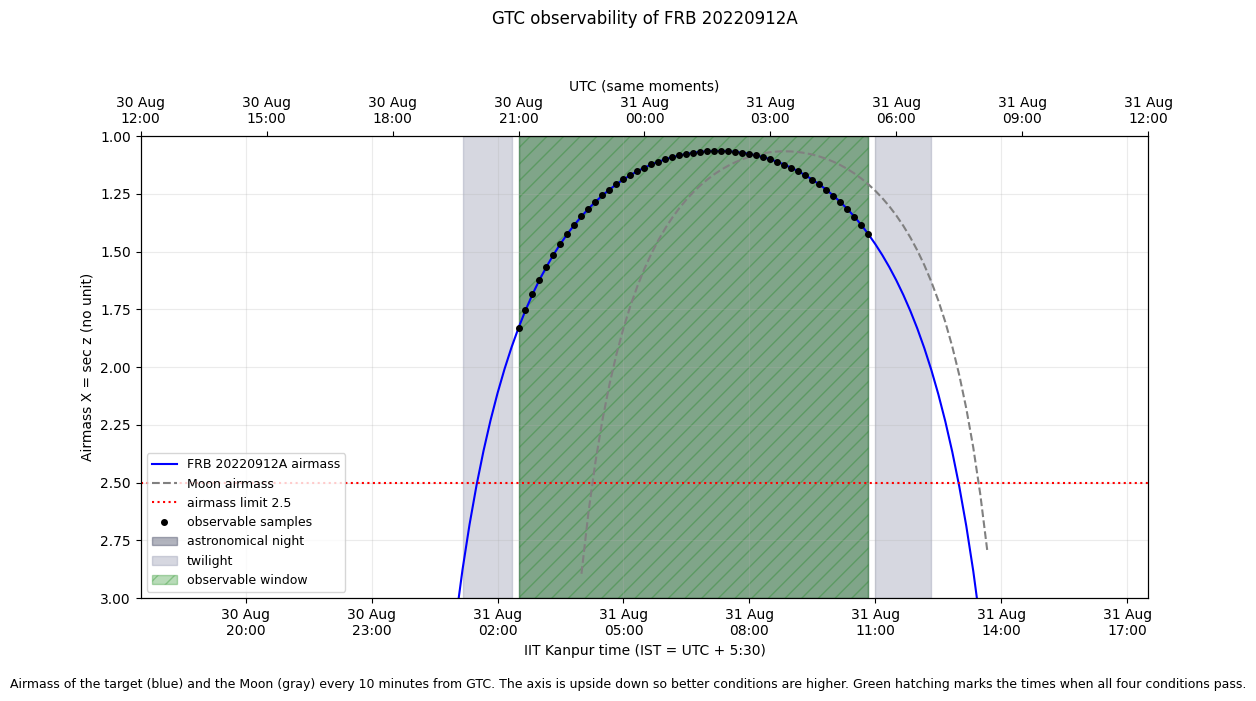


Saved: assignment_outputs/frb_20220912a_gtc_airmass.png


In [ ]:

from matplotlib.patches import Patch


def stitch_windows(times, visibility_state):
    windows = []
    start = None
    for i, is_visible in enumerate(visibility_state):
        if is_visible and start is None:
            start = i
        if not is_visible and start is not None:
            windows.append((start, i - 1))
            start = None
    if start is not None:
        windows.append((start, len(visibility_state) - 1))
    return windows



test = np.zeros(len(times), dtype=bool)
print("nothing True    :", stitch_windows(times, test))
test[3] = True
test[10:13] = True
test[-1] = True
print("single/gap/last :", stitch_windows(times, test))
print()

observing_windows = stitch_windows(times, preferred_visibility)

print("Observing windows for", FRB_NAME)
for number, (start, stop) in enumerate(observing_windows, start=1):
    hours = (times[stop] - times[start]).to_value(u.hour)
    middle = (start + stop) // 2
    print(f" Window {number}")
    print("   IST:", format_iitk(times[start]), "->", format_iitk(times[stop]))
    print("   UTC:", format_utc(times[start]), "->", format_utc(times[stop]))
    print(f"   length {hours:.2f} h, best airmass {np.nanmin(target_airmass[start:stop + 1]):.3f},"
          f" Moon is {moon_labels[middle]}")


plot_times = times.to_datetime(timezone=timezone.utc)
night = stitch_windows(times, sun_altitude <= MAX_SUN_ALTITUDE_DEG)
twilight = stitch_windows(times, (sun_altitude > MAX_SUN_ALTITUDE_DEG) & (sun_altitude <= 0))

figure, axis = plt.subplots(figsize=(13, 6))

for start, stop in twilight:
    axis.axvspan(plot_times[start], plot_times[stop], color="#8a8fa8", alpha=0.35)
for start, stop in night:
    axis.axvspan(plot_times[start], plot_times[stop], color="#232946", alpha=0.35)
for start, stop in observing_windows:
    axis.axvspan(plot_times[start], plot_times[stop], color="green", alpha=0.28, hatch="//")

axis.plot(plot_times, target_airmass, "-", color="blue", label=FRB_NAME + " airmass")
axis.plot(plot_times, moon_airmass, "--", color="gray", label="Moon airmass")
axis.axhline(MAX_AIRMASS, color="red", linestyle=":", label="airmass limit 2.5")
axis.plot(np.array(plot_times)[preferred_visibility], target_airmass[preferred_visibility],
          "o", color="black", markersize=4, label="observable samples")

axis.set_ylim(3, 1)
axis.set_xlim(plot_times[0], plot_times[-1])
axis.set_ylabel("Airmass X = sec z (no unit)")
axis.set_xlabel("IIT Kanpur time (IST = UTC + 5:30)")
axis.xaxis.set_major_locator(mdates.HourLocator(interval=3, tz=IITK_TIMEZONE))
axis.xaxis.set_major_formatter(mdates.DateFormatter("%d %b\n%H:%M", tz=IITK_TIMEZONE))
axis.grid(alpha=0.25)
axis.set_title("GTC observability of " + FRB_NAME, pad=40)

bands = [Patch(color="#232946", alpha=0.35, label="astronomical night"),
         Patch(color="#8a8fa8", alpha=0.35, label="twilight"),
         Patch(color="green", alpha=0.28, hatch="//", label="observable window")]
axis.legend(handles=axis.get_legend_handles_labels()[0] + bands, loc="lower left", fontsize=9)

top_axis = axis.twiny()
top_axis.set_xlim(axis.get_xlim())
top_axis.xaxis.set_major_locator(mdates.HourLocator(interval=3, tz=timezone.utc))
top_axis.xaxis.set_major_formatter(mdates.DateFormatter("%d %b\n%H:%M", tz=timezone.utc))
top_axis.set_xlabel("UTC (same moments)")

figure.text(0.5, -0.04, "Airmass of the target (blue) and the Moon (gray) every 10 minutes from GTC. "
            "The axis is upside down so better conditions are higher. Green hatching marks the times "
            "when all four conditions pass.", ha="center", fontsize=9)

figure_path = OUTPUT_DIR / "frb_20220912a_gtc_airmass.png"
figure.savefig(figure_path, dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved:", figure_path)

**Conclusion.** FRB is observable only during the intervals where every required condition is simultaneously satisfied.


**Limit of the 10-minute grid.** the 10-minute grid samples the conditions discretely, so a true visibility boundary can occur between two samples. A window shorter than
10 minutes could be missed completely. For a repeating FRB, whose bursts are short and unpredictable,
that is worth remembering.

# Part F. All-sky observability (2 assessed marks + 2 optional bonus marks)

The previous parts established the physical ingredients needed for an observing decision. The next questions reuse those same ideas at increasing scale: first one source on one date, then a weekly all-sky GTC visibility animation over one year.

For Q19–Q20, use the geometric/airmass GTC visibility rule developed in the notebook: the source or sky position must be above the horizon, satisfy the GTC airmass limit, and be inside astronomical night. Do not include the Moon in these questions.


## Q19. Find the GTC visibility window of the repeating FRB on one date [2 marks]

Treat FRB 20220912A as a repeating source at its fixed ICRS/J2000 position. For `2026-09-01`, calculate its visibility from GTC across the full UTC day using the same HEALPix-style visibility logic: astronomical night, target altitude above the horizon, and target airmass no larger than 2.5. Report the start and end of each contiguous visibility interval in UTC and IIT Kanpur time, together with the total visible duration in hours.

This is a **single source**, not an all-sky calculation.


In [ ]:

day_times = Time("2026-09-01T00:00:00", scale="utc") + np.arange(24 * 60 + 1) * u.min

day_frame = AltAz(obstime=day_times, location=gtc_location, pressure=0 * u.hPa)
day_altitude = frb_icrs.transform_to(day_frame).alt.deg

with solar_system_ephemeris.set("builtin"):
    day_sun_altitude = get_sun(day_times).transform_to(day_frame).alt.deg

day_airmass = np.array(frb_icrs.transform_to(day_frame).secz)
day_airmass[(day_altitude <= 0) | (day_airmass < 1)] = np.nan

day_visible = ((day_sun_altitude <= MAX_SUN_ALTITUDE_DEG)
               & (day_altitude > 0)
               & (day_airmass <= MAX_AIRMASS))

print("Rule: dark sky, above the horizon, airmass at most 2.5. Moon ignored here.\n")

total = 0.0
for number, (start, stop) in enumerate(stitch_windows(day_times, day_visible), start=1):
    hours = (day_times[stop] - day_times[start]).to_value(u.hour)
    total += hours
    print(f" Window {number}")
    print("   UTC:", format_utc(day_times[start]), "-", format_utc(day_times[stop]))
    print("   IST:", format_iitk(day_times[start]), "-", format_iitk(day_times[stop]))
    print(f"   length {hours:.2f} h")

print(f"\nTotal visible time on 2026-09-01: {total:.2f} h")

Rule: dark sky, above the horizon, airmass at most 2.5. Moon ignored here.

 Window 1
   UTC: 2026-09-01 00:00:00 UTC - 2026-09-01 05:28:00 UTC
   IST: 2026-09-01 05:30:00 IST - 2026-09-01 10:58:00 IST
   length 5.47 h
 Window 2
   UTC: 2026-09-01 20:55:00 UTC - 2026-09-02 00:00:00 UTC
   IST: 2026-09-02 02:25:00 IST - 2026-09-02 05:30:00 IST
   length 3.08 h

Total visible time on 2026-09-01: 8.55 h


## Q20. Generate a one-year GTC visibility animation [2 bonus marks]

Use the same **all-sky GTC visibility** model over the next year, starting on **2026-08-30** and sampled every 7 days. With a weekly cadence, the final sample within the 365-day window is **2027-08-29**. For each date, compute the HEALPix visibility map using the same GTC astronomical-night, altitude, and airmass conditions developed earlier.

Save each weekly map as a PNG frame and combine the frames into a GIF. The animation should show how the observable sky from GTC changes through the year. Use a moderate HEALPix resolution so that the calculation is practical.

Briefly describe what changes across the animation and why the observable region changes with date.

In [27]:


import imageio.v2 as imageio

NSIDE = 32
WEEKS = 53
NIGHT_STEP_MINUTES = 20

frames_dir = OUTPUT_DIR / "q20_frames"
frames_dir.mkdir(exist_ok=True)


pixel_ra, pixel_dec = hp.pix2ang(NSIDE, np.arange(hp.nside2npix(NSIDE)), lonlat=True)


altitude_limit = np.degrees(np.arcsin(1 / MAX_AIRMASS))
print(f"Airmass {MAX_AIRMASS} means altitude above {altitude_limit:.1f} deg")


def altitude_from_gtc(ra, dec, lst):

    phi = np.radians(GTC_LATITUDE_DEG)
    dec = np.radians(dec)
    H = np.radians(lst - ra)
    sin_altitude = np.sin(phi) * np.sin(dec) + np.cos(phi) * np.cos(dec) * np.cos(H)
    return np.degrees(np.arcsin(np.clip(sin_altitude, -1, 1)))


frames = []
for week in range(WEEKS):
    date = Time("2026-08-30T00:00:00", scale="utc") + week * 7 * u.day


    day = date + np.arange(0, 24 * 60, NIGHT_STEP_MINUTES) * u.min
    day_frame = AltAz(obstime=day, location=gtc_location, pressure=0 * u.hPa)
    with solar_system_ephemeris.set("builtin"):
        sun_altitude = get_sun(day).transform_to(day_frame).alt.deg
    night = day[sun_altitude <= MAX_SUN_ALTITUDE_DEG]


    hours = np.zeros(len(pixel_ra))
    for lst in night.sidereal_time("apparent", longitude=gtc_location.lon).deg:
        altitude = altitude_from_gtc(pixel_ra, pixel_dec, lst)
        hours += (altitude >= altitude_limit) * NIGHT_STEP_MINUTES / 60

    hp.mollview(hours, cmap="viridis", min=0, max=10,
                unit="hours visible that night",
                title="Sky GTC can observe, night of " + date.iso[:10])
    hp.graticule(dpar=30, dmer=30)

    frame = frames_dir / f"frame_{week:03d}.png"
    plt.savefig(frame, dpi=80, bbox_inches="tight")
    plt.close("all")
    frames.append(frame)

gif_path = OUTPUT_DIR / "gtc_visibility_one_year.gif"
imageio.mimsave(gif_path, [imageio.imread(f) for f in frames], duration=0.35, loop=0)
print("Saved", len(frames), "frames and the animation:", gif_path)

Airmass 2.5 means altitude above 23.6 deg


Saved 53 frames and the animation: assignment_outputs/gtc_visibility_one_year.gif


**What the animation shows.** Each frame is a map of the whole sky, coloured by how many hours that
direction can be observed from GTC during one night.

The bright band **slides sideways in right ascension** and goes all the way round over the year. This
is the main change. At night we see the half of the sky facing away from the Sun, and the Sun moves
right round the sky in a year, so the part of the sky that is up at midnight moves with it.

The band also **gets thicker and thinner**. That is night length: winter nights are long, so every
direction collects more hours, and summer nights are short.

# New Section

## Submission checklist

- Restart the kernel and run every cell from top to bottom.
- Keep units attached during physical calculations.
- Use UTC internally; show IIT Kanpur time whenever reporting a civil clock time.
- Label Local Sidereal Time as LST, never IST.
- Keep the exact `visibility(altitude, airmass, sun_altitude, moon_separation)` interface.
- Confirm `assignment_outputs/frb_20220912a_gtc_airmass.png` exists and is non-empty.
- Confirm the Q20 one-year GTC GIF and its generated weekly frame PNGs are present.

## Compact glossary

- **Astropy quantity:** a numerical value stored together with a physical unit.
- **UTC:** the standard time scale used to identify an instant worldwide.
- **IST:** Indian Standard Time, the IIT Kanpur civil clock, UTC+05:30.
- **JD/MJD:** continuous astronomical day counts; MJD is JD minus 2,400,000.5.
- **ICRS:** a modern standard equatorial frame expressed with RA and Dec.
- **Galactic coordinates:** longitude $l$ and latitude $b$ referred to the Milky Way.
- **Ecliptic coordinates:** longitude $\lambda$ and latitude $\beta$ referred to Earth's orbital plane; longitude begins at the vernal equinox.
- **Angular separation:** the shortest great-circle angle between two directions on the celestial sphere.
- **Mollweide projection:** an equal-area elliptical map of the full celestial sphere; Matplotlib expects longitude and latitude in radians.
- **LST:** Local Sidereal Time, an astronomical angle determined by time and longitude.
- **Hour angle:** $H=\mathrm{LST}-\alpha$; zero at meridian transit.
- **Transit:** passage across the local meridian; usually the highest geometric altitude.
- **AltAz:** a horizon frame determined by observer location and time.
- **Zenith distance:** angular distance from the zenith, $z=90^\circ-h$.
- **Airmass:** approximate atmospheric path length relative to the zenith.
- **Astronomical darkness:** Sun altitude at or below $-18^\circ$ in this assignment.
- **Observable interval:** consecutive samples satisfying every printed condition.

- **HEALPix:** a hierarchical equal-area pixelization of the celestial sphere; each pixel can store an astronomical quantity such as visibility time.
- **Visibility time:** the amount of time a source satisfies the observing constraints during a specified interval.
- **Repeating FRB:** an FRB that can produce bursts on multiple occasions, so a future observing schedule can be planned for its fixed sky position.
